# 1. Introduction to the Real-World Problem

El cáncer de mama es uno de los tipos de cáncer más comunes en el mundo, comúnmente se da entre las mujeres y se produce cuando algunas células de la mama comienzan a crecer de manera anormal formando un tumor.  Con el tiempo, el crecimiento de estos tumores puede afectar negativamente a todo el cuerpo. 

La principal problemática de esta enfermedad es que en las etapas iniciales del cáncer es muy difícil encontrar síntomas evidentes de que se está formando el tumor, debido a esto pueden haber muchos casos que a pesar de que se podrían haber evitado fácilmente con un tratamiento temprano pero que terminan siendo mortales para el paciente. Por esta razón, la detección temprana es de gran importancia para aumentar las probabilidades de tratamiento exitoso y supervivencia. Utilizando métodos de diagnóstico como la mamografía, los ultrasonidos y el análisis de biopsias se pueden identificar las características de los síntomas presentes entre los pacientes. 

Los modelos de machine learning nos pueden ayudar a mejorar estos procesos de diagnóstico, siendo estos capaces de análizar los datos obtenidos e identificar patrónes que se repiten en los pacientes que padecen de la enfermedad. 

# Wisconsin Breast Cancer Dataset

Este Dataset tiene aplicación médica, enfocada en el diágnostico de cáncer de mama.
Entre las variables predictivas se encuentran: el radio, la textura, perímetro, área, suavidad, compacidad, concavidad, puntos de concavidad, la simetría y la dimensión fractal. Se calcula la media, la desviación estándar y "peor" (media de los 3 valores más grandes) de cada feature, dando un total de 30.
La variable objetivo es Diagnosis (Maligno y Benigno).

# Data Cleaning

Es importante manejar los valores faltantes, dependiendo de los datos se puede decidir si es necesario eliminar una columna o reemplazar los valores faltantes con alguna medida de tendencia central.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset (Añadiendo los títulos de las columnas, proveniente de la documentación del dataset)
column_names = ['id', 'diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']

df = pd.read_csv('wdbc.data', names=column_names)

# Limpieza de la columna ID (irrelevante) y mapeo de la columna 'diagnosis' para convertirla en valores numéricos
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Validación de datos y manejo de valores faltantes
# Conteo por columna y suma de todas las columnas.
if df.isnull().sum().sum():
    print("Existen valores faltantes en el dataset.")
else:
    print("No existen valores faltantes en el dataset.")

No existen valores faltantes en el dataset.


In [5]:
df

,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# Exploratory Data Analysis

In [ ]:
df.describe()

,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Las escalas de los datos son muy distintas, lo que podría llegar a ocasionar que se asignen valores de relevancia de manera errónea.

In [3]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

Con esto identificamos que de las 569 observaciónes que hay en el dataset 357 estan catalogadas como un diagnóstico negativo del cáncer y 212 como positivo del cáncer. A pesar de que hay un ligero desbalance en los datos estos igual siguén estando lo suficientemente balanceados como para llevar a cabo el modelo. 

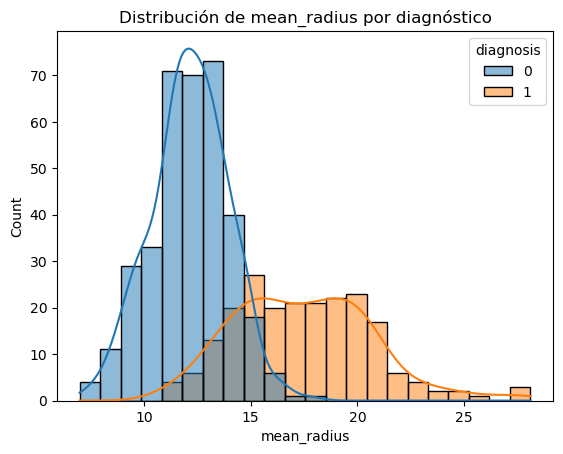

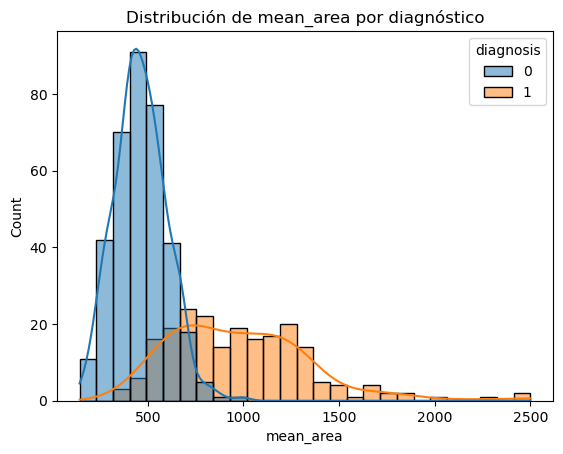

In [ ]:
# Histograma de las variables 'mean_radius' y 'mean_area' para observar su distribución
sns.histplot(data = df, x='mean_radius', hue='diagnosis', kde=True)
plt.title('Distribución de mean_radius por diagnóstico')
plt.show()

sns.histplot(data = df, x='mean_area', hue='diagnosis', kde=True)
plt.title('Distribución de mean_area por diagnóstico')
plt.show()

Las celúlas cancerígenas muestran una tendencia a tener núcleos más grandes, esto puede indicar un alto valor predictivo de estas variables.

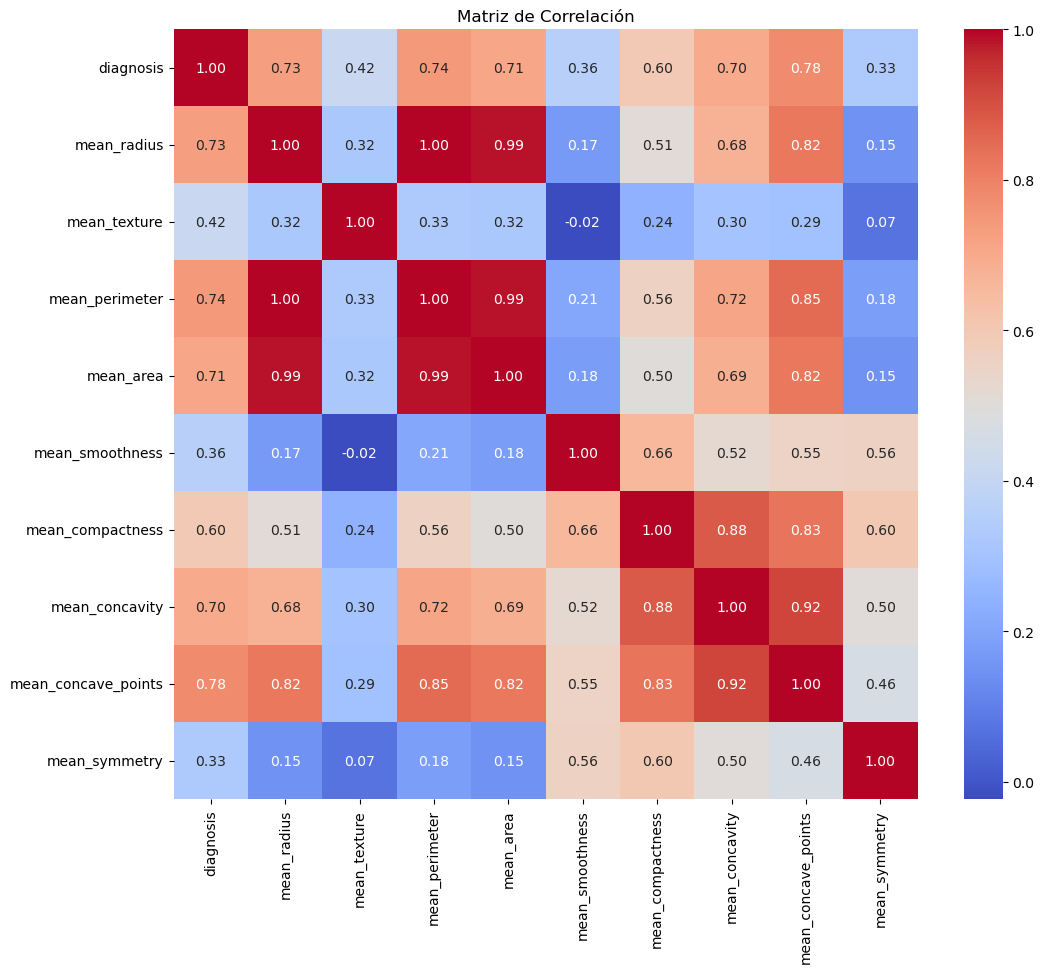

In [ ]:
# Análisis de correlación entre las variables para identificar posibles relaciones
correlation_matrix = df.iloc[:, 0:10].corr() # Primeros 10 valores para claridad
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Las variables geométricas muestran una alta correlación entre ellas, al ser variables colineales puede ser beneficioso utilizar alguna técnica para reducir la dimensionalidad. Al ser variables geométricas, podría servir obtener una variable derivada que las represente a todas.

Igualmente, es posible notar la alta relación entre compactness, concavity y concave_points, por lo que este sería el segundo grupo de variables que muestran muticolinealidad.

Todas las features de estos grupos muestran una correlación de al menos .7, exceptuando "mean_concavity" con .6, con el diagnóstico. Mostrando un posible alto valor predictivo de estas variables.

# 2. Design and Training of the Single-Neuron Model


In [22]:
# Importar librerías para la construcción del modelo de red neuronal
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA


In [ ]:
# Global seed para reproducibilidad
tf.random.set_seed(4500)

# Preparación de los datos para el modelo
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Estandarización de las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Architectura de la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación del modelo con el optimizador Adam y la función de pérdida de entropía cruzada binaria

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Hiperparámetros para el entrenamiento
EPOCHS = 100
LEARNING_RATE = 0.001
BATCH_SIZE = 32
VALIDATION_RATIO = 0.2


Descripción de Hiperparámetros:
- EPOCHS: Es el número de veces que se va a repetir el entrenamiento. Esto significa que el modelo repetirá el entrenamiento 100 veces.
- LEARNING_RATE: Determina que tanto van a cambiar los pesos de cada variable en cada entrenamiento. 
- BATCH_SIZE: Determina el número de muestras que se usan antes de cambiar los pesos del entrenamiento. 
- VALIDATION_RATIO: Es el porcentaje de los datos que se usarán para la validación del modelo tras cada entrenamiento. En este caso se usará el 20% de los datos. 

# 3. Learning Curve Analysis


In [ ]:
# Evaluación del modelo antes del entrenamiento
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2544 - loss: 1.1667  
Test Accuracy: 0.2544


In [ ]:
# Entrenamiento del modelo con validación
history = model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALIDATION_RATIO)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3159 - loss: 1.0307 - val_accuracy: 0.3736 - val_loss: 0.9370
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3599 - loss: 0.9387 - val_accuracy: 0.4286 - val_loss: 0.8492
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4286 - loss: 0.8552 - val_accuracy: 0.4835 - val_loss: 0.7708
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4918 - loss: 0.7804 - val_accuracy: 0.5714 - val_loss: 0.7021
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5659 - loss: 0.7141 - val_accuracy: 0.6044 - val_loss: 0.6430
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6374 - loss: 0.6559 - val_accuracy: 0.6264 - val_loss: 0.5927
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7033 - loss: 0.6050 - val_accuracy: 0.7033 - val_loss: 0.5498
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5605 - val_accuracy: 0.7473 - v

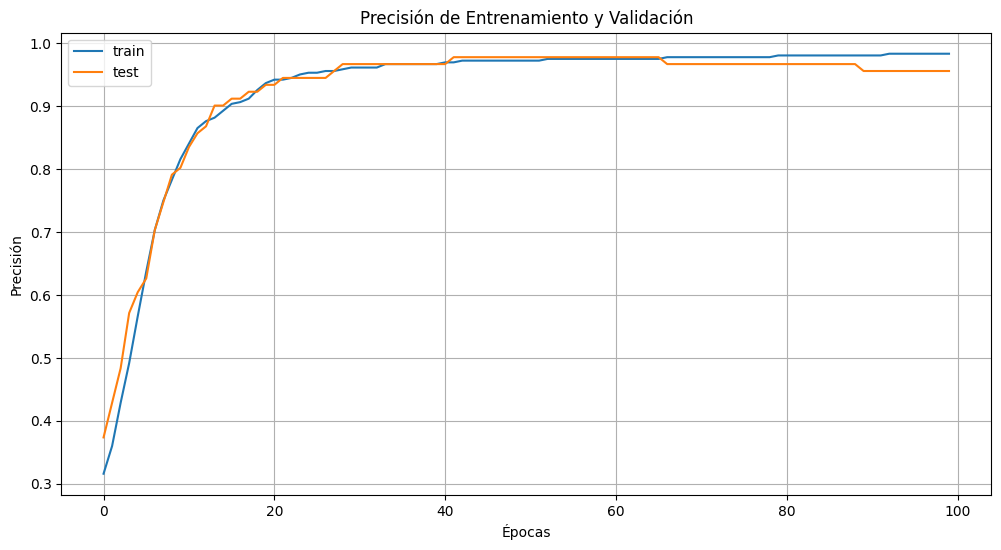

In [ ]:
# Gráfica de precisión de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(['train', 'test'])
plt.grid()

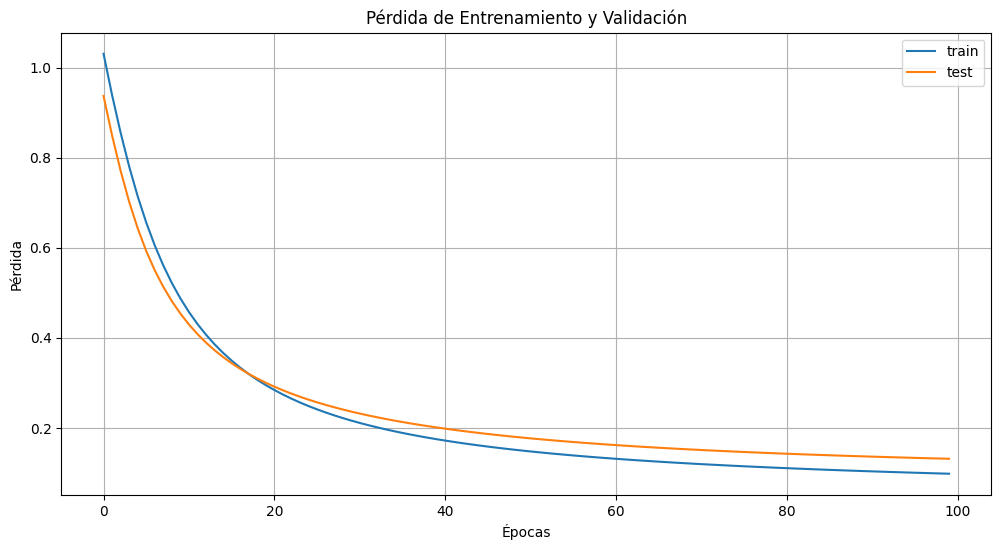

In [ ]:
# Gráfica de pérdida de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(['train', 'test'])
plt.grid()

## Interpretación de las curvas

Las curvas muestran que la precisión de entrenamiento y validación aumentan y se estabilizan en valores altos (0.97–0.98), manteniéndose muy cercanas entre sí. Además, la pérdida disminuye de forma constante en ambos conjuntos, con tendencias similares.

Esto indica que no hay underfitting, ya que el modelo alcanza alta precisión, ni overfitting, porque la diferencia entre entrenamiento y validación es mínima. Por lo tanto, el modelo presenta appropriate fitting, ya que aprende correctamente y generaliza bien a los datos de validación.

# 4. Model Evaluation and Testing Data

In [ ]:
#Predecir (probabilidades) y convertir a clases (0 o 1)
y_prob = model.predict(X_test_scaled)          # probabilidad de clase 1
y_pred = (y_prob >= 0.5).astype(int).ravel()   # umbral 0.5 -> clase

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



Confusion matrix:
 [[71  0]
 [ 2 41]]


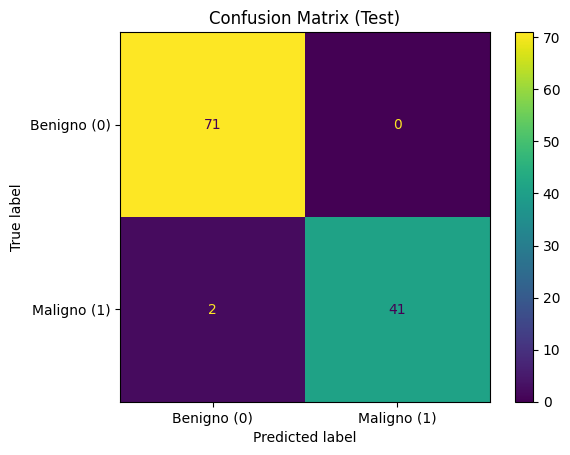

In [ ]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

La matriz de confusión muestra que el modelo clasificó correctamente 71 casos benignos y 42 malignos, con solo dos errores, donde un tumor maligno fue clasificado como benigno. Esto indica un desempeño muy alto del modelo en el conjunto de prueba.

In [ ]:
#Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print("\nPrecision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))


Precision: 1.0
Recall: 0.9535
Specificity: 1.0
F1-score: 0.9762


##Interpretación de las métricas


*   La precision = 1.0 indica que todos los casos que el modelo clasificó como malignos realmente lo eran. Esto significa que el modelo no generó falsos positivos, es decir, ningún tumor benigno fue clasificado incorrectamente como maligno.

*   El recall = 0.9535 mide la capacidad del modelo para identificar correctamente los casos malignos. Este valor indica que el modelo detecta aproximadamente el 95.4% de los tumores malignos, lo que significa que solo un caso maligno fue clasificado incorrectamente como benigno (falso negativo).

* La specificity = 1.0 indica que todos los tumores benignos fueron correctamente clasificados como benignos. Esto muestra que el modelo tiene una excelente capacidad para distinguir los casos no cancerígenos.

* El F1-score = 0.9762 combina precision y recall en una sola métrica, proporcionando una medida del equilibrio entre ambas. Un valor cercano a 1 indica que el modelo tiene un muy buen rendimiento general en la clasificación.

En el contexto del diagnóstico de cáncer de mama, la métrica más importante es recall (sensibilidad), ya que un falso negativo implicaría que un tumor maligno no sea detectado, lo que podría retrasar el tratamiento del paciente. Por lo tanto, es fundamental que el modelo identifique correctamente la mayor cantidad posible de casos malignos.

En general, el modelo presenta un desempeño muy alto, con métricas cercanas a 1 y solo dos errores de clasificación en el conjunto de prueba. Esto indica que el modelo tiene una muy buena capacidad para diferenciar entre tumores benignos y malignos, por lo que su rendimiento puede considerarse muy adecuado para este problema de clasificación.



# 5. Save the Model

In [ ]:
# Guardar el modelo entrenado
model.save("breast_cancer_model.keras")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [ ]:
# Cargar el modelo guardado
loaded_model = load_model("breast_cancer_model.keras")

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [ ]:
loss, accuracy = loaded_model.evaluate(X_test_scaled, y_test)

print("Accuracy del modelo cargado:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9825 - loss: 0.0961 
Accuracy del modelo cargado: 0.9824561476707458


Guardar un modelo entrenado permite reutilizarlo sin tener que volver a entrenarlo, lo que ahorra tiempo y recursos computacionales. Además, facilita su implementación en aplicaciones reales y permite compartirlo o reproducir los resultados en otros sistemas.

# 6. Apply PCA to the Original Dataset

In [7]:
# Cargar el dataset para PCA
dfPCA = pd.read_csv('wdbc.data', names=column_names)

# Limpieza de la columna ID (irrelevante) y mapeo de la columna 'diagnosis' para convertirla en valores numéricos
dfPCA = dfPCA.drop(columns=['id'])
dfPCA['diagnosis'] = dfPCA['diagnosis'].map({'M': 1, 'B': 0})

In [8]:
# Estandarización de las características para PCA
XPCA = dfPCA.drop(columns=['diagnosis'])
yPCA = dfPCA['diagnosis']
XPCA_scaled = StandardScaler().fit_transform(XPCA)

# Matriz de covarianza
cov_matrix = np.cov(XPCA_scaled, rowvar=False)

cov_df = pd.DataFrame(cov_matrix, index=XPCA.columns, columns=XPCA.columns)

In [9]:
# Eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalores:\n", eigenvalues)

Eigenvalores:
 [1.33049908e+01 5.70137460e+00 2.82291016e+00 1.98412752e+00
 1.65163324e+00 1.20948224e+00 6.76408882e-01 4.77456255e-01
 4.17628782e-01 3.51310875e-01 2.94433153e-01 2.61621161e-01
 2.41782421e-01 1.57286149e-01 9.43006956e-02 8.00034045e-02
 5.95036135e-02 5.27114222e-02 4.95647002e-02 1.33279057e-04
 7.50121413e-04 1.59213600e-03 6.91261258e-03 8.19203712e-03
 1.55085271e-02 1.80867940e-02 2.43836914e-02 2.74877113e-02
 3.12142606e-02 3.00256631e-02]


In [10]:
# Varianza explicada en porcentaje
explained_variance = eigenvalues / np.sum(eigenvalues) * 100
accumulated_variance = 0

# Hasta alcanzar 95% de la varianza explicada
for i, val in enumerate(explained_variance):
    if accumulated_variance < 95:
        accumulated_variance = np.sum(explained_variance[:i+1])
        print(f"Componente {i+1}: {val:.2f}% de la varianza explicada, Varianza explicada: {accumulated_variance:.2f}%")
        k = i + 1


Componente 1: 44.27% de la varianza explicada, Varianza explicada: 44.27%
Componente 2: 18.97% de la varianza explicada, Varianza explicada: 63.24%
Componente 3: 9.39% de la varianza explicada, Varianza explicada: 72.64%
Componente 4: 6.60% de la varianza explicada, Varianza explicada: 79.24%
Componente 5: 5.50% de la varianza explicada, Varianza explicada: 84.73%
Componente 6: 4.02% de la varianza explicada, Varianza explicada: 88.76%
Componente 7: 2.25% de la varianza explicada, Varianza explicada: 91.01%
Componente 8: 1.59% de la varianza explicada, Varianza explicada: 92.60%
Componente 9: 1.39% de la varianza explicada, Varianza explicada: 93.99%
Componente 10: 1.17% de la varianza explicada, Varianza explicada: 95.16%


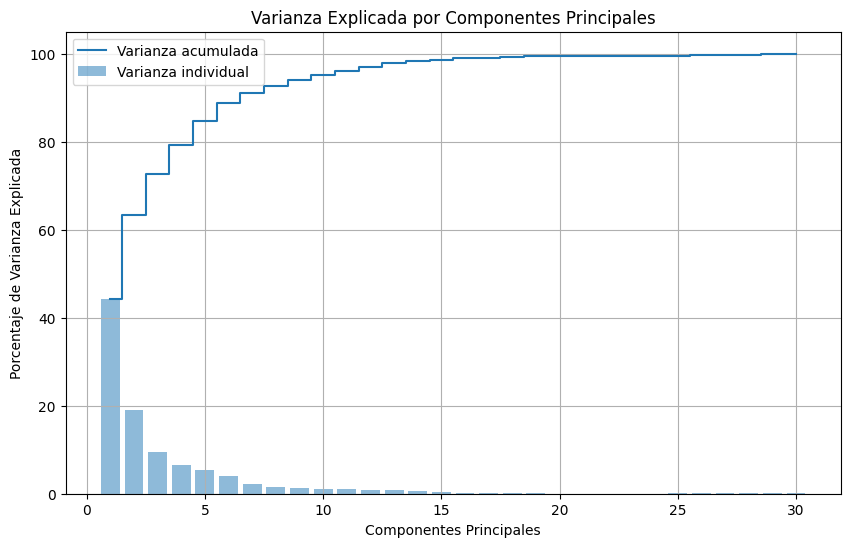

In [11]:
# explained variance ratio plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Varianza acumulada')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.legend()
plt.grid()

La gráfica muestra que con aproximadamente 10 componentes principales se explica cerca del 95% de la varianza del dataset. Esto significa que la dimensionalidad se redujo de 30 variables originales a 10 componentes, manteniendo la mayor parte de la información.

Esto también indica que existe redundancia en los datos, ya que muchas variables están correlacionadas y pueden representarse mediante un menor número de componentes principales.

# 7. Train a New Single-Neuron Model Using PCA Features

In [19]:
#Preparación de los datos
X = dfPCA.drop(columns=['diagnosis'])
y = dfPCA['diagnosis']

#División de lo datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Estandarización de las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Train PCA shape:", X_train_pca.shape)
print("Test PCA shape:", X_test_pca.shape)

Train PCA shape: (455, 10)
Test PCA shape: (114, 10)


In [25]:
tf.random.set_seed(4500)

# Hiperparámetros para el entrenamiento
EPOCHS = 100
BATCH_SIZE = 32
VALIDATION_RATIO = 0.2

In [26]:
#Arquitectura del modelo
model_pca = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compilación del modelo con el optimizador Adam y la función de pérdida de entropía cruzada binaria
model_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Entrenamiento del modelo
history_pca = model_pca.fit(
    X_train_pca, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_RATIO,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5431 - loss: 0.8378 - val_accuracy: 0.5275 - val_loss: 0.8938
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5519 - loss: 0.8137 - val_accuracy: 0.5385 - val_loss: 0.8681
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5579 - loss: 0.7909 - val_accuracy: 0.5714 - val_loss: 0.8428
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5684 - loss: 0.7687 - val_accuracy: 0.5714 - val_loss: 0.8182
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5698 - loss: 0.7472 - val_accuracy: 0.5824 - val_loss: 0.7943
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5799 - loss: 0.7264 - val_accuracy: 0.5934 - val_loss: 0.7711
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5966 - loss: 0.7062 - val_accuracy: 0.5934 - val_loss: 0.7486
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6042 - loss: 0.6868 - val_accuracy: 0.

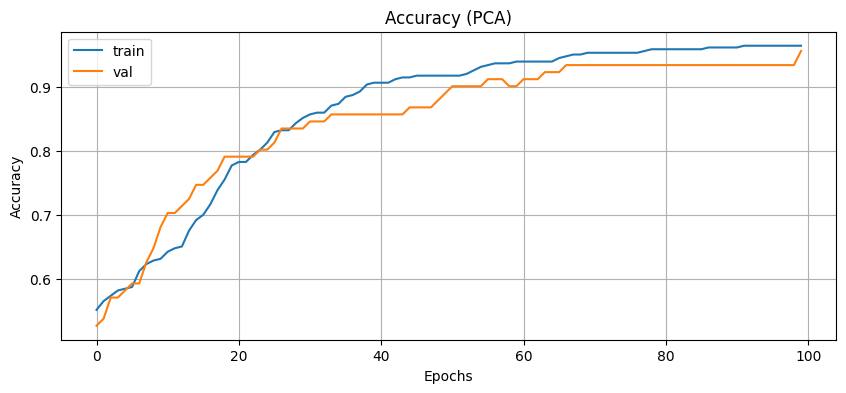

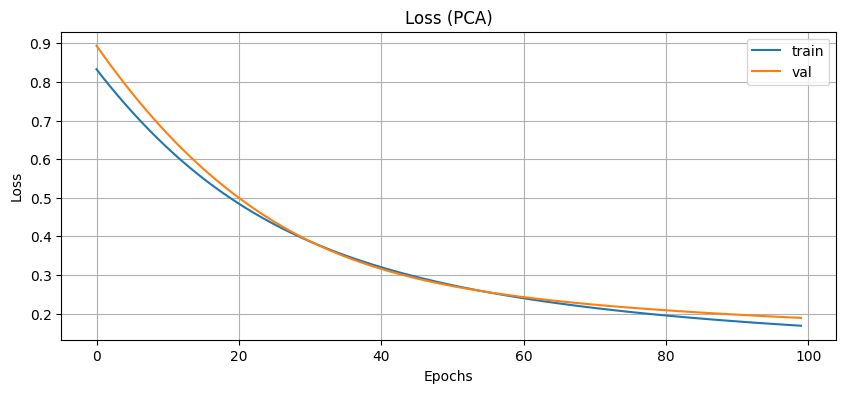

In [27]:
# Gráfica de precisión de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(10,4))
plt.plot(history_pca.history['accuracy'], label='train')
plt.plot(history_pca.history['val_accuracy'], label='val')
plt.title('Accuracy (PCA)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de pérdida de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(10,4))
plt.plot(history_pca.history['loss'], label='train')
plt.plot(history_pca.history['val_loss'], label='val')
plt.title('Loss (PCA)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Interpretación de las curvas (PCA)

Las curvas muestran que la precisión de entrenamiento y validación aumentan gradualmente hasta valores cercanos a 0.95 y se mantienen bastante cercanas entre sí. Además, la pérdida disminuye de forma constante en ambos conjuntos.

Esto indica que no hay underfitting ni overfitting, ya que el modelo aprende bien y la diferencia entre entrenamiento y validación es pequeña. Por lo tanto, el modelo presenta appropriate fitting

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Confusion Matrix:
 [[69  2]
 [ 2 41]]


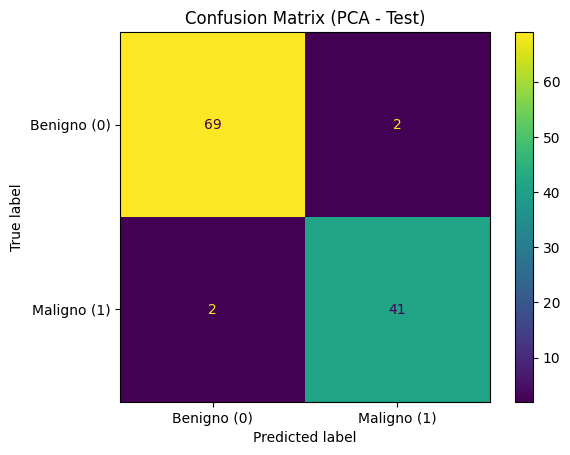

In [28]:
#Predecir (probabilidades) y convertir a clases (0 o 1)
y_prob = model_pca.predict(X_test_pca)
y_pred = (y_prob >= 0.5).astype(int).ravel()

#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (PCA - Test)")
plt.show()


La matriz de confusión muestra que el modelo clasificó correctamente 69 tumores benignos y 41 malignos, mientras que cometió 4 errores en total: 2 falsos positivos (benignos clasificados como malignos) y 2 falsos negativos (malignos clasificados como benignos).

In [29]:
#Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))

Precision: 0.9535
Recall: 0.9535
Specificity: 0.9718
F1-score: 0.9535


Las métricas reflejan un buen desempeño del modelo. La precision (0.9535) indica que aproximadamente el 95.35% de los casos predichos como malignos realmente lo son. El recall (0.9535) muestra que el modelo detecta alrededor del 95.35% de los tumores malignos reales. La specificity (0.9718) indica que el 97.18% de los tumores benignos se clasifican correctamente, evitando la mayoría de los falsos positivos. Finalmente, el F1-score (0.9535) confirma un buen equilibrio entre precisión y recall.

En general, el modelo con PCA presenta un rendimiento alto y equilibrado, aunque con algunos errores de clasificación.

In [30]:
model_pca.save("breast_cancer_model_pca.keras")

loaded_model_pca = tf.keras.models.load_model("breast_cancer_model_pca.keras")
loss, acc = loaded_model_pca.evaluate(X_test_pca, y_test, verbose=0)

print("Loaded PCA model accuracy:", round(acc, 4))

Loaded PCA model accuracy: 0.9649


# 8. Performance Comparison
| Metric      | Original Model | PCA Model |
| ----------- | -------------- | --------- |
| Precision   | 1.0000         | 0.9535    |
| Recall      | 0.9767         | 0.9535    |
| Specificity | 1.0000         | 0.9718    |
| F1-score    | 0.9882         | 0.9535    |

Al comparar el modelo con características originales y el modelo con PCA, ambos presentan un desempeño alto. Sin embargo, el modelo original obtiene métricas ligeramente mejores en precisión, recall, especificidad y F1-score.

Las curvas de aprendizaje de ambos modelos muestran un comportamiento similar: la precisión aumenta y la pérdida disminuye de forma estable, con curvas de entrenamiento y validación cercanas. Esto indica que no hay señales de overfitting ni underfitting y que el entrenamiento es estable.

El uso de PCA reduce la dimensionalidad del dataset de 30 variables a 10 componentes, conservando aproximadamente el 95% de la varianza. Esto confirma que existía redundancia en los datos. No obstante, esta reducción provoca una ligera disminución en el desempeño del modelo.

En conclusión, aunque PCA permite simplificar el conjunto de datos y reducir la cantidad de variables necesarias para el entrenamiento, el modelo con características originales presenta el mejor desempeño predictivo. Esto es especialmente importante en un problema médico como el diagnóstico de cáncer, donde es fundamental maximizar la precisión del modelo y minimizar los errores de clasificación. Por esta razón, el modelo con todas las variables originales sería la opción más adecuada para su implementación, mientras que el modelo con PCA podría considerarse en situaciones donde se requiera reducir la complejidad del modelo o mejorar la eficiencia computacional.

# 9. Personal Conclusions

Carlos.

Se aprendió acerca de las ventajas de usar o no el Principal Component Analysis. Entendimos la utilidad de una red neuronal simple en un problema de clasificación binaria, como en este caso médico donde buscabamos clasificar tumores malignos y benignos.

El PCA fue muy útil para reducir la dimensionalidad del dataset. Originalmente se contaban con 30 características distintas, y gracias a PCA se logró reducir a solo 10 características manteniendo el 95% de la información, mostrando así la redundancia original de la información.

Sin embargo, en un entorno real, no utilizaríamos PCA debido a la pérdida de interpretabilidad. En los entornos médicos es necesario poder explicar con claridad lo que sucede, PCA lo que hace es combinar linealmente distintas características que dejan de representar elementos "reales".

https://github.com/Carlos-HC/Single-Neuron-Network-Team9

Ramón

En este trabajo se desarrolló y evaluó un modelo de red neuronal de una sola neurona para clasificar tumores como benignos o malignos. Durante el proceso se aprendió cómo preparar los datos, entrenar un modelo y evaluar su desempeño.

Se observó que una red neuronal simple puede obtener muy buenos resultados en un problema de clasificación binaria. Además, el uso de PCA permitió reducir el número de variables del dataset, mostrando que existía redundancia en los datos. Sin embargo, también se notó una ligera disminución en el desempeño del modelo al usar PCA.

Como limitación, el modelo utilizado es bastante simple. En el futuro, se podrían probar modelos más complejos o ajustar mejor los parámetros para mejorar el rendimiento.

Este trabajo permitió comprender mejor cómo funcionan los modelos de aprendizaje automático y cómo técnicas como PCA pueden ayudar a simplificar los datos manteniendo un buen desempeño.
https://github.com/ramonlerma-cr/Single-Neuron-Network-with-and-without-PCA

Bernardo 

Esta tarea tenía como objetivo ayudarnos a entender mejor como es que funcióna el modelo de una sola neurona y entender como es que puede PCA afectar al desempeño de esta. Para esto se desarrollaron dos modelos de una sola neurona (sin y con PCA) que identifican y clasifican tumores como malignos o benignos, todo esto utlizando el dataset "Wisconsin Breast Cancer Dataset" en donde hay datos relacionados al diagnóstico de cáncer de mama. 

Al final el desempeño de ambos modelos fue bastante bueno. Debido a que PCA elimina variables para simplificar el conjunto de datos este acabó con un desempeño ligeramente peor al que se entrenó con todas las variables, aunque aún así fue capaz de generar muy buenas predicciónes al mismo tiempo que redujo de forma significativa la complejidad del dataset (de 31 a 10 variables). A pesar de esto se opto por seleccionar al modelo sin PCA para ser usado en casos reales ya que al ser una problemática de tanto riesgo como lo puede ser el cáncer de mama hay mucha más prioridad por mantener una predicción lo más correcta posible. 

Como conclusión creo que esta tarea me ayudó a entender como funcionan los modelos de una sola neurona, así como identificar los efectos que puede tener el PCA sobre sus predicciónes y desempeño en general. 

# 10. References


UCI Machine Learning Repository. (1995). Breast Cancer Wisconsin (Diagnostic) Dataset.
Disponible en: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic